# Few-Shot Target Adaptation
RoBERTa-base, DistilBERT-base-uncased, and BERT-base-uncased: few-shot adaptation on the worst cross-category transfer pair for each model.

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Toys_and_Games",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Toys"
]

FILE_STEMS = {
    "Electronics":                "electronics",
    "Books":                      "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Toys_and_Games":             "toys",
}

FEW_SHOT_SIZES      = [16, 32, 64]
FEW_SHOT_EPOCHS     = 3
FEW_SHOT_LR         = 1e-5
FEW_SHOT_BATCH_SIZE = 8
MAX_LENGTH          = 128
EVAL_BATCH_SIZE     = 32
RANDOM_SEED         = 104
DRIVE_BASE          = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast, BertForSequenceClassification,
    TrainingArguments, Trainer,
)
from sklearn.metrics import accuracy_score, f1_score
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda
Mounted at /content/drive


In [4]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


def sample_few_shot(df_train: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    half = n // 2
    pos = df_train[df_train["label"] == 1].sample(half, random_state=seed)
    neg = df_train[df_train["label"] == 0].sample(half, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1":       f1_score(labels, preds, average="macro")}


def adapt_and_evaluate(n_shots, model_class, tokenizer, src_model_dir,
                       df_tgt_train, test_ds, save_prefix) -> dict:
    few_shot_df = sample_few_shot(df_tgt_train, n_shots, RANDOM_SEED)
    train_ds    = ReviewDataset(few_shot_df["text"], few_shot_df["label"], tokenizer, MAX_LENGTH)
    model       = model_class.from_pretrained(src_model_dir)
    save_dir    = f"{MODELS_DIR}/{save_prefix}_{n_shots}shot"

    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=save_dir,
            num_train_epochs=FEW_SHOT_EPOCHS,
            per_device_train_batch_size=FEW_SHOT_BATCH_SIZE,
            per_device_eval_batch_size=EVAL_BATCH_SIZE,
            learning_rate=FEW_SHOT_LR,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            fp16=torch.cuda.is_available(),
            seed=RANDOM_SEED,
            logging_steps=10,
            report_to="none",
        ),
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
    )
    print(f"  Adapting with {n_shots} examples ...")
    trainer.train()
    out   = trainer.predict(test_ds)
    preds = np.argmax(out.predictions, axis=-1)
    y_true = test_ds.labels.numpy()
    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds, average="macro")
    print(f"    {n_shots}-shot -> acc={acc:.3f}  f1={f1:.3f}")
    return {"few_shot_size": n_shots, "accuracy": acc, "macro_f1": f1}

## 1  RoBERTa-base

In [5]:
rob_acc = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv", index_col=0)
rob_f1_mat = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv", index_col=0)

m = rob_acc.values.astype(float)
n = m.shape[0]
masked = np.ma.masked_array(m, np.eye(n, dtype=bool))
si_rob, ti_rob = np.unravel_index(masked.argmin(), m.shape)

SOURCE_ROB = CATEGORIES[si_rob]
TARGET_ROB = CATEGORIES[ti_rob]
ZERO_SHOT_ACC_ROB = float(m[si_rob, ti_rob])
ZERO_SHOT_F1_ROB  = float(rob_f1_mat.values[si_rob, ti_rob])

print(f"RoBERTa worst pair: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}")
print(f"  Zero-shot acc={ZERO_SHOT_ACC_ROB:.3f}  f1={ZERO_SHOT_F1_ROB:.3f}")

RoBERTa worst pair: Home & Kitchen -> Books
  Zero-shot acc=0.580  f1=0.573


In [6]:
src_stem_rob = FILE_STEMS[SOURCE_ROB]
tgt_stem_rob = FILE_STEMS[TARGET_ROB]

tokenizer_rob = RobertaTokenizerFast.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem_rob}")

df_tgt_train_rob = pd.read_csv(f"{DATA_DIR}/{tgt_stem_rob}_train.csv")
df_tgt_test_rob  = pd.read_csv(f"{DATA_DIR}/{tgt_stem_rob}_test.csv")
df_tgt_train_rob["text"] = df_tgt_train_rob["text"].fillna("").astype(str)
df_tgt_test_rob["text"]  = df_tgt_test_rob["text"].fillna("").astype(str)

test_ds_rob = ReviewDataset(df_tgt_test_rob["text"], df_tgt_test_rob["label"],
                            tokenizer_rob, MAX_LENGTH)

print(f"Target train: {len(df_tgt_train_rob)}  test: {len(df_tgt_test_rob)}")

Target train: 3500  test: 750


In [7]:
fewshot_rob = [{"few_shot_size": 0, "accuracy": ZERO_SHOT_ACC_ROB, "macro_f1": ZERO_SHOT_F1_ROB}]

src_model_dir_rob = f"{MODELS_DIR}/roberta_{src_stem_rob}"
save_prefix_rob   = f"roberta_fewshot_{src_stem_rob}_to_{tgt_stem_rob}"

for k in FEW_SHOT_SIZES:
    fewshot_rob.append(adapt_and_evaluate(
        k, RobertaForSequenceClassification, tokenizer_rob,
        src_model_dir_rob, df_tgt_train_rob, test_ds_rob, save_prefix_rob
    ))

rob_fewshot_df = pd.DataFrame(fewshot_rob)
rob_fewshot_df.to_csv(f"{RESULTS_DIR}/fewshot_results_roberta.csv", index=False)
print()
print("RoBERTa few-shot results:")
print(rob_fewshot_df.to_string(index=False))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Adapting with 16 examples ...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.693332,0.500000,0.333333
2,No log,0.693336,0.500000,0.333333
3,No log,0.693346,0.500000,0.333333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

    64-shot -> acc=0.500  f1=0.333

RoBERTa few-shot results:
 few_shot_size  accuracy  macro_f1
             0      0.58  0.572855
            16      0.50  0.333333
            32      0.50  0.333333
            64      0.50  0.333333


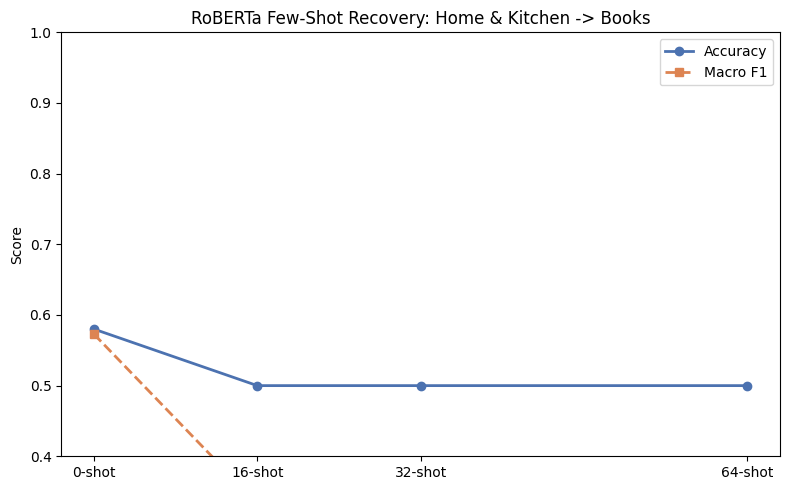

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = rob_fewshot_df["few_shot_size"].values
ax.plot(x, rob_fewshot_df["accuracy"], marker="o", linewidth=2, label="Accuracy",  color="#4c72b0")
ax.plot(x, rob_fewshot_df["macro_f1"], marker="s", linewidth=2, label="Macro F1",  color="#dd8452", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(["0-shot", "16-shot", "32-shot", "64-shot"])
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Score")
ax.set_title(f"RoBERTa Few-Shot Recovery: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fewshot_recovery_roberta.png", dpi=150)
plt.show()

## 2  DistilBERT-base-uncased

In [9]:
distil_acc = pd.read_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix.csv", index_col=0)
distil_f1_mat = pd.read_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix_f1.csv", index_col=0)

m_d = distil_acc.values.astype(float)
masked_d = np.ma.masked_array(m_d, np.eye(n, dtype=bool))
si_distil, ti_distil = np.unravel_index(masked_d.argmin(), m_d.shape)

SOURCE_DISTIL = CATEGORIES[si_distil]
TARGET_DISTIL = CATEGORIES[ti_distil]
ZERO_SHOT_ACC_DISTIL = float(m_d[si_distil, ti_distil])
ZERO_SHOT_F1_DISTIL  = float(distil_f1_mat.values[si_distil, ti_distil])

print(f"DistilBERT worst pair: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}")
print(f"  Zero-shot acc={ZERO_SHOT_ACC_DISTIL:.3f}  f1={ZERO_SHOT_F1_DISTIL:.3f}")

DistilBERT worst pair: Books -> Home & Kitchen
  Zero-shot acc=0.833  f1=0.832


In [10]:
src_stem_distil = FILE_STEMS[SOURCE_DISTIL]
tgt_stem_distil = FILE_STEMS[TARGET_DISTIL]

tokenizer_distil = DistilBertTokenizerFast.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_distil}")

df_tgt_train_distil = pd.read_csv(f"{DATA_DIR}/{tgt_stem_distil}_train.csv")
df_tgt_test_distil  = pd.read_csv(f"{DATA_DIR}/{tgt_stem_distil}_test.csv")
df_tgt_train_distil["text"] = df_tgt_train_distil["text"].fillna("").astype(str)
df_tgt_test_distil["text"]  = df_tgt_test_distil["text"].fillna("").astype(str)

test_ds_distil = ReviewDataset(df_tgt_test_distil["text"], df_tgt_test_distil["label"],
                               tokenizer_distil, MAX_LENGTH)

print(f"Target train: {len(df_tgt_train_distil)}  test: {len(df_tgt_test_distil)}")

Target train: 3500  test: 750


In [11]:
fewshot_distil = [{"few_shot_size": 0, "accuracy": ZERO_SHOT_ACC_DISTIL, "macro_f1": ZERO_SHOT_F1_DISTIL}]

src_model_dir_distil = f"{MODELS_DIR}/distilbert_{src_stem_distil}"
save_prefix_distil   = f"distilbert_fewshot_{src_stem_distil}_to_{tgt_stem_distil}"

for k in FEW_SHOT_SIZES:
    fewshot_distil.append(adapt_and_evaluate(
        k, DistilBertForSequenceClassification, tokenizer_distil,
        src_model_dir_distil, df_tgt_train_distil, test_ds_distil, save_prefix_distil
    ))

distil_fewshot_df = pd.DataFrame(fewshot_distil)
distil_fewshot_df.to_csv(f"{RESULTS_DIR}/fewshot_results_distilbert.csv", index=False)
print()
print("DistilBERT few-shot results:")
print(distil_fewshot_df.to_string(index=False))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Adapting with 16 examples ...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.358470,0.852000,0.851861
2,No log,0.357658,0.846667,0.846664
3,No log,0.360518,0.849333,0.849331


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


    64-shot -> acc=0.849  f1=0.849

DistilBERT few-shot results:
 few_shot_size  accuracy  macro_f1
             0  0.833333  0.832432
            16  0.846667  0.846664
            32  0.852000  0.851861
            64  0.849333  0.849331


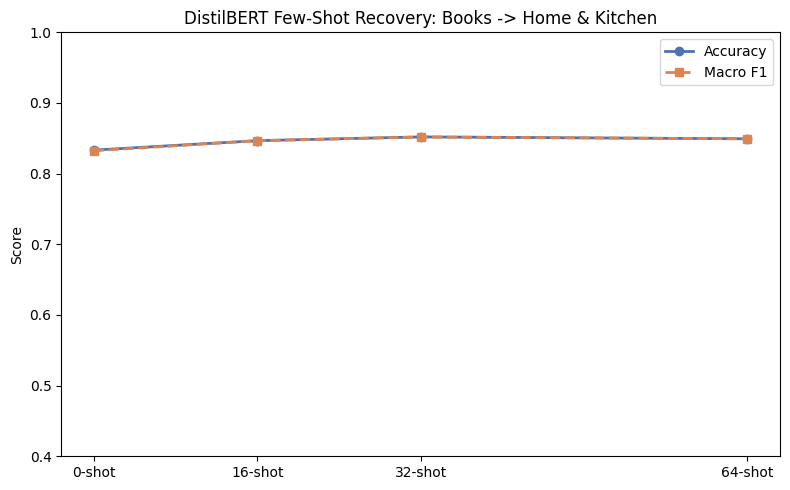

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
x = distil_fewshot_df["few_shot_size"].values
ax.plot(x, distil_fewshot_df["accuracy"], marker="o", linewidth=2, label="Accuracy", color="#4c72b0")
ax.plot(x, distil_fewshot_df["macro_f1"], marker="s", linewidth=2, label="Macro F1", color="#dd8452", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(["0-shot", "16-shot", "32-shot", "64-shot"])
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Score")
ax.set_title(f"DistilBERT Few-Shot Recovery: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fewshot_recovery_distilbert.png", dpi=150)
plt.show()

## 3  BERT-base-uncased

In [13]:
bert_acc_mat = pd.read_csv(f"{RESULTS_DIR}/bert_transfer_matrix.csv", index_col=0)
bert_f1_mat  = pd.read_csv(f"{RESULTS_DIR}/bert_transfer_matrix_f1.csv", index_col=0)

m_b = bert_acc_mat.values.astype(float)
masked_b = np.ma.masked_array(m_b, np.eye(n, dtype=bool))
si_bert, ti_bert = np.unravel_index(masked_b.argmin(), m_b.shape)

SOURCE_BERT = CATEGORIES[si_bert]
TARGET_BERT = CATEGORIES[ti_bert]
ZERO_SHOT_ACC_BERT = float(m_b[si_bert, ti_bert])
ZERO_SHOT_F1_BERT  = float(bert_f1_mat.values[si_bert, ti_bert])

print(f"BERT worst pair: {CATEGORY_LABELS[si_bert]} -> {CATEGORY_LABELS[ti_bert]}")
print(f"  Zero-shot acc={ZERO_SHOT_ACC_BERT:.3f}  f1={ZERO_SHOT_F1_BERT:.3f}")

src_stem_bert = FILE_STEMS[SOURCE_BERT]
tgt_stem_bert = FILE_STEMS[TARGET_BERT]

tokenizer_bert = BertTokenizerFast.from_pretrained(f"{MODELS_DIR}/bert_{src_stem_bert}")

df_tgt_train_bert = pd.read_csv(f"{DATA_DIR}/{tgt_stem_bert}_train.csv")
df_tgt_test_bert  = pd.read_csv(f"{DATA_DIR}/{tgt_stem_bert}_test.csv")
df_tgt_train_bert["text"] = df_tgt_train_bert["text"].fillna("").astype(str)
df_tgt_test_bert["text"]  = df_tgt_test_bert["text"].fillna("").astype(str)

test_ds_bert = ReviewDataset(df_tgt_test_bert["text"], df_tgt_test_bert["label"], tokenizer_bert, MAX_LENGTH)

print(f"Target train: {len(df_tgt_train_bert)}  test: {len(df_tgt_test_bert)}")

BERT worst pair: Home & Kitchen -> Books
  Zero-shot acc=0.843  f1=0.842
Target train: 3500  test: 750


In [14]:
fewshot_bert = [{"few_shot_size": 0, "accuracy": ZERO_SHOT_ACC_BERT, "macro_f1": ZERO_SHOT_F1_BERT}]

src_model_dir_bert = f"{MODELS_DIR}/bert_{src_stem_bert}"
save_prefix_bert   = f"bert_fewshot_{src_stem_bert}_to_{tgt_stem_bert}"

for k in FEW_SHOT_SIZES:
    fewshot_bert.append(adapt_and_evaluate(
        k, BertForSequenceClassification, tokenizer_bert,
        src_model_dir_bert, df_tgt_train_bert, test_ds_bert, save_prefix_bert
    ))

bert_fewshot_df = pd.DataFrame(fewshot_bert)
bert_fewshot_df.to_csv(f"{RESULTS_DIR}/fewshot_results_bert.csv", index=False)
print()
print("BERT few-shot results:")
print(bert_fewshot_df.to_string(index=False))

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

  Adapting with 16 examples ...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.335071,0.861333,0.861270
2,No log,0.337662,0.861333,0.861329
3,No log,0.336501,0.862667,0.862655


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

    64-shot -> acc=0.879  f1=0.879

BERT few-shot results:
 few_shot_size  accuracy  macro_f1
             0  0.842667  0.841653
            16  0.861333  0.861270
            32  0.866667  0.866620
            64  0.878667  0.878665


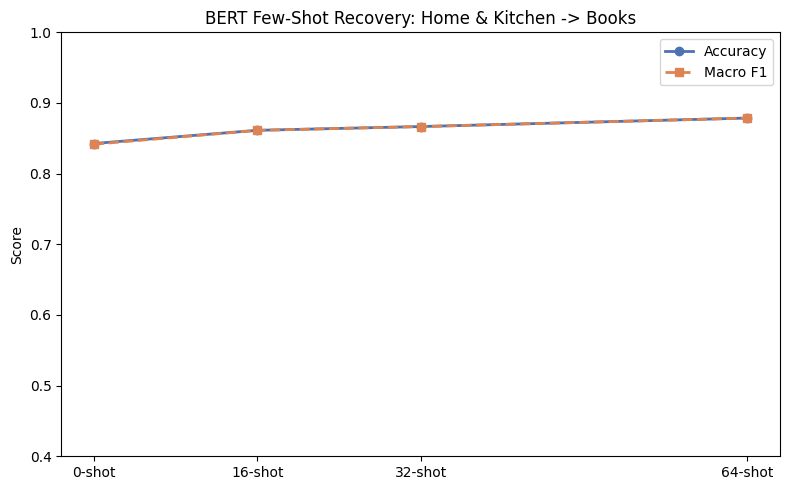

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
x = bert_fewshot_df["few_shot_size"].values
ax.plot(x, bert_fewshot_df["accuracy"], marker="o", linewidth=2, label="Accuracy", color="#4c72b0")
ax.plot(x, bert_fewshot_df["macro_f1"], marker="s", linewidth=2, label="Macro F1", color="#dd8452", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(["0-shot", "16-shot", "32-shot", "64-shot"])
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Score")
ax.set_title(f"BERT Few-Shot Recovery: {CATEGORY_LABELS[si_bert]} -> {CATEGORY_LABELS[ti_bert]}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fewshot_recovery_bert.png", dpi=150)
plt.show()

## 3  Comparison

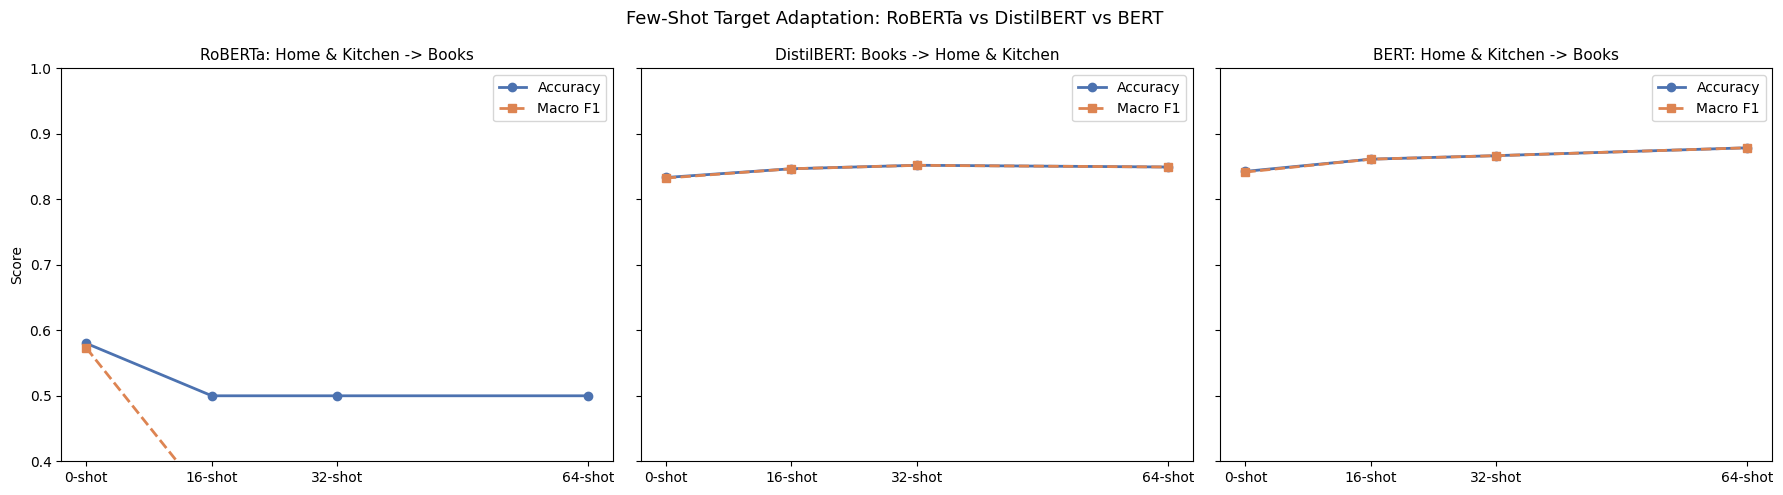


Summary:
  RoBERTa: Home & Kitchen -> Books  zero-shot=0.580  best=0.580 (0-shot)
  DistilBERT: Books -> Home & Kitchen  zero-shot=0.833  best=0.852 (32-shot)
  BERT: Home & Kitchen -> Books  zero-shot=0.843  best=0.879 (64-shot)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, df, title in [
    (axes[0], rob_fewshot_df,   f"RoBERTa: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}"),
    (axes[1], distil_fewshot_df, f"DistilBERT: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}"),
    (axes[2], bert_fewshot_df,   f"BERT: {CATEGORY_LABELS[si_bert]} -> {CATEGORY_LABELS[ti_bert]}"),
]:
    x = df["few_shot_size"].values
    ax.plot(x, df["accuracy"], marker="o", linewidth=2, label="Accuracy", color="#4c72b0")
    ax.plot(x, df["macro_f1"], marker="s", linewidth=2, label="Macro F1", color="#dd8452", linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(["0-shot", "16-shot", "32-shot", "64-shot"])
    ax.set_ylim(0.4, 1.0)
    ax.set_title(title, fontsize=11)
    ax.legend()

axes[0].set_ylabel("Score")
plt.suptitle("Few-Shot Target Adaptation: RoBERTa vs DistilBERT vs BERT", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fewshot_recovery_comparison.png", dpi=150)
plt.show()

print()
print("Summary:")
for label, df, si, ti in [
    ("RoBERTa",    rob_fewshot_df,   si_rob,   ti_rob),
    ("DistilBERT", distil_fewshot_df, si_distil, ti_distil),
    ("BERT",       bert_fewshot_df,   si_bert,   ti_bert),
]:
    best_row = df.loc[df["accuracy"].idxmax()]
    print(f"  {label}: {CATEGORY_LABELS[si]} -> {CATEGORY_LABELS[ti]}  "
          f"zero-shot={df.iloc[0]['accuracy']:.3f}  best={best_row['accuracy']:.3f} ({int(best_row['few_shot_size'])}-shot)")